Fetching Wikipedia...
Preprocessing...

Corpus stats:
{'sentences': 378, 'tokens': 5200, 'vocab': 1806}

Training model...

Vocabulary size: 1806

luna
  was             0.6608
  nguyen          0.6227
  seeks           0.6190
  rename          0.6180
  stamp           0.6153
  biag            0.6142
  limay           0.6136
  featuring       0.6133

general
  ger             0.6854
  juli            0.6757
  licerio         0.6741
  nimo            0.6685
  east            0.6681
  llanera         0.6665
  profile         0.6647
  municipalities  0.6625

army
  journeyed       0.7898
  counterinsurgency 0.7896
  regular         0.7670
  ricarte         0.7370
  weakness        0.7366
  begin           0.7363
  major           0.7362
  revolutionary   0.7351

military
  maxilom         0.8172
  arcadio         0.8169
  jubilation      0.8035
  cebu            0.8017
  established     0.8014
  apply           0.7879
  theories        0.7812
  sought          0.7798

philippines
  pasig 

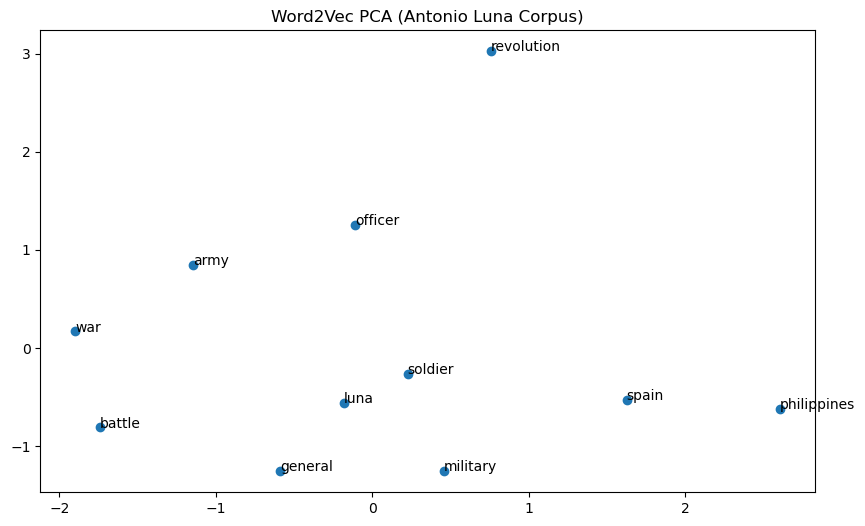

In [ ]:
"""
Train Skip-gram with Negative Sampling on a Wikipedia article,
then evaluate the embedding model with intrinsic tests and custom test sets.

Requirements:
    pip install requests beautifulsoup4 nltk gensim scikit-learn scipy

Optional:
    python -m nltk.downloader punkt stopwords
"""

import re
import json
import random
from collections import Counter
from typing import List, Tuple, Dict

import requests
from bs4 import BeautifulSoup
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from gensim.models import Word2Vec
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt


WIKI_URL = "https://en.wikipedia.org/wiki/Antonio_Luna"
RANDOM_SEED = 42


def ensure_nltk():
    for r in ["punkt"]:
        try:
            nltk.data.find(f"tokenizers/{r}")
        except LookupError:
            nltk.download(r)


def fetch_wikipedia_article(url: str) -> str:
    headers = {"User-Agent": "Mozilla/5.0"}
    resp = requests.get(url, headers=headers, timeout=30)
    resp.raise_for_status()

    soup = BeautifulSoup(resp.text, "html.parser")
    content = soup.find("div", {"id": "mw-content-text"})

    paragraphs = content.find_all(["p", "li"])
    text = " ".join(p.get_text(" ", strip=True) for p in paragraphs)

    text = re.sub(r"\[[0-9]+\]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text


def preprocess_text(text: str) -> List[List[str]]:
    sentences = sent_tokenize(text)

    processed = []

    for sent in sentences:
        sent = sent.lower()
        sent = re.sub(r"[^a-z0-9\s]", " ", sent)
        tokens = word_tokenize(sent)

        cleaned = [
            t for t in tokens
            if t.isalpha() and len(t) > 2
        ]

        if len(cleaned) >= 3:
            processed.append(cleaned)

    return processed


def corpus_stats(sentences):
    flat = [w for s in sentences for w in s]
    return {
        "sentences": len(sentences),
        "tokens": len(flat),
        "vocab": len(set(flat))
    }


def train_model(sentences):
    model = Word2Vec(
        sentences=sentences,
        vector_size=100,
        window=10,
        min_count=1,
        sg=1,
        negative=10,
        epochs=50,
        seed=RANDOM_SEED,
        workers=4
    )
    return model


def has_word(model, w):
    return w in model.wv


def cosine(model, w1, w2):
    return float(cosine_similarity(
        model.wv[w1].reshape(1, -1),
        model.wv[w2].reshape(1, -1)
    )[0][0])


def evaluate_relatedness(model, pairs):
    results = []

    for w1, w2, gold in pairs:
        if has_word(model, w1) and has_word(model, w2):
            pred = cosine(model, w1, w2)
            results.append((w1, w2, gold, pred))

    return results


def print_neighbors(model, words):
    for w in words:
        if has_word(model, w):
            print(f"\n{w}")
            for n, s in model.wv.most_similar(w, topn=8):
                print(f"  {n:15s} {s:.4f}")
        else:
            print(f"\n{w}: OOV")


def plot_pca(model, words):
    vecs, labels = [], []

    for w in words:
        if has_word(model, w):
            vecs.append(model.wv[w])
            labels.append(w)

    if len(vecs) < 2:
        print("Not enough words for PCA")
        return

    pca = PCA(n_components=2)
    reduced = pca.fit_transform(vecs)

    plt.figure(figsize=(10, 6))
    plt.scatter(reduced[:, 0], reduced[:, 1])

    for i, label in enumerate(labels):
        plt.annotate(label, (reduced[i, 0], reduced[i, 1]))

    plt.title("Word2Vec PCA (Antonio Luna Corpus)")
    plt.show()


def run_pipeline():
    random.seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)
    ensure_nltk()

    print("Fetching Wikipedia...")
    text = fetch_wikipedia_article(WIKI_URL)

    print("Preprocessing...")
    sentences = preprocess_text(text)

    print("\nCorpus stats:")
    print(corpus_stats(sentences))

    print("\nTraining model...")
    model = train_model(sentences)

    print("\nVocabulary size:", len(model.wv))


    probe_words = [
        "luna", "general", "army", "military",
        "philippines", "revolution", "officer",
        "soldier", "war", "spain"
    ]

    print_neighbors(model, probe_words)

    relatedness_test = [
        ("luna", "general", 0.95),
        ("luna", "army", 0.90),
        ("military", "soldier", 0.85),
        ("war", "battle", 0.90),
        ("spain", "philippines", 0.80),
        ("army", "military", 0.95),
        ("luna", "kitchen", 0.05),
        ("military", "banana", 0.02),
    ]

    print("\nRelatedness results:")
    results = evaluate_relatedness(model, relatedness_test)

    for w1, w2, gold, pred in results:
        print(f"{w1:12s}-{w2:12s} | gold={gold:.2f} pred={pred:.4f}")

    return model


model = run_pipeline()

plot_pca(model, [
    "luna", "general", "war", "battle", "army",
    "philippines", "military", "revolution",
    "officer", "soldier", "spain"
])